# SARIMA Manual - Modelo Aplicado a demanda energética Alemania

# Cambiar por los datos a nivel semanal

Se desarrolla un modelo ARIMA estacional aplicando los pasos definidos mediante la metodología Box-Jenkins. Los datos provienen de SMARD - base de datos que contiene información relacionada al consumo de energía en Alemania.

Fuente: https://www.smard.de/en/downloadcenter/download-market-data/?downloadAttributes=%7B"selectedCategory":2,"selectedSubCategory":5,"selectedRegion":"DE","selectedFileType":"CSV","from":1420066800000,"to":1767221999999%7D)''

In [8]:
import numpy as np
import pandas as pd
import itertools
import statsmodels.api as sm
import time
import json
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.tsaplots import acf, pacf
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
from scipy.signal import periodogram, welch
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
warnings.filterwarnings('ignore')
import matplotlib.dates as mdates
warnings.filterwarnings("ignore")
#plt.style.use("seaborn-v0_8-darkgrid")
#sns.set_palette("viridis")


Se definen las funciones requeridas para la validar la estacionariedad de la serie (aplicación del cliterio de Dickey-Fuller y gráfica de la ACF y la PACF)

In [9]:
def check_stationarity(ts):
    result = adfuller(ts, autolag='AIC')
    p_value = result[1]
    print(f"ADF Statistic: {result[0]:.16f}")
    print(f"p-value: {p_value:.16f}")
    print('Estacionaria' if p_value < 0.05 else 'No estacionaria')

def plot_acf_pacf(ts, n_lags=100):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17,6))

    plot_acf(
        ts,
        ax=ax1,
        lags=n_lags,
        alpha=0.05,
        vlines_kwargs={"colors": "black"},
        marker="o",
        color="black",
        markersize=4
    )

    plot_pacf(
        ts,
        ax=ax2,
        lags=n_lags,
        method="ywm",
        alpha=0.05,
        vlines_kwargs={"colors": "black"},
        marker="o",
        color="black",
        markersize=4
    )

    # cambiar color de intervalos de confianza
    for ax in [ax1, ax2]:
        for collection in ax.collections:
            collection.set_facecolor("lightgray")
            collection.set_alpha(0.6)

    return plt.show()

Se cargan los datos (inicialmente los datos estaban dados en días, lo que se hizo fue tomar la media semanal de las observaciones, dado que se tomaron 10 años de datos. Este proceso ya fue realizado antes de cargar los datos. La fecha mostrada es el lunes de cada semana). El orden de las observaciones está dado en millones

In [10]:
data_demand =  pd.read_csv("../../../data/csv/EC_GER_Weekly.csv")
df_data_demand = pd.DataFrame(data_demand.copy()) # copia del df de precios de cierre como df
df_data_demand["Start date"] = pd.to_datetime(df_data_demand["Start date"]) # conversión a formato fecha
df_data_close = df_data_demand.sort_values(by="Start date", ascending=True) # se ordena por fecha ascendente
df_data_close.head()


,Start date,value
0,2015-01-05,1.240580e+06
1,2015-01-12,1.465239e+06
2,2015-01-19,1.479857e+06
3,2015-01-26,1.516270e+06
4,2015-02-02,1.507588e+06


Se grafican los datos 

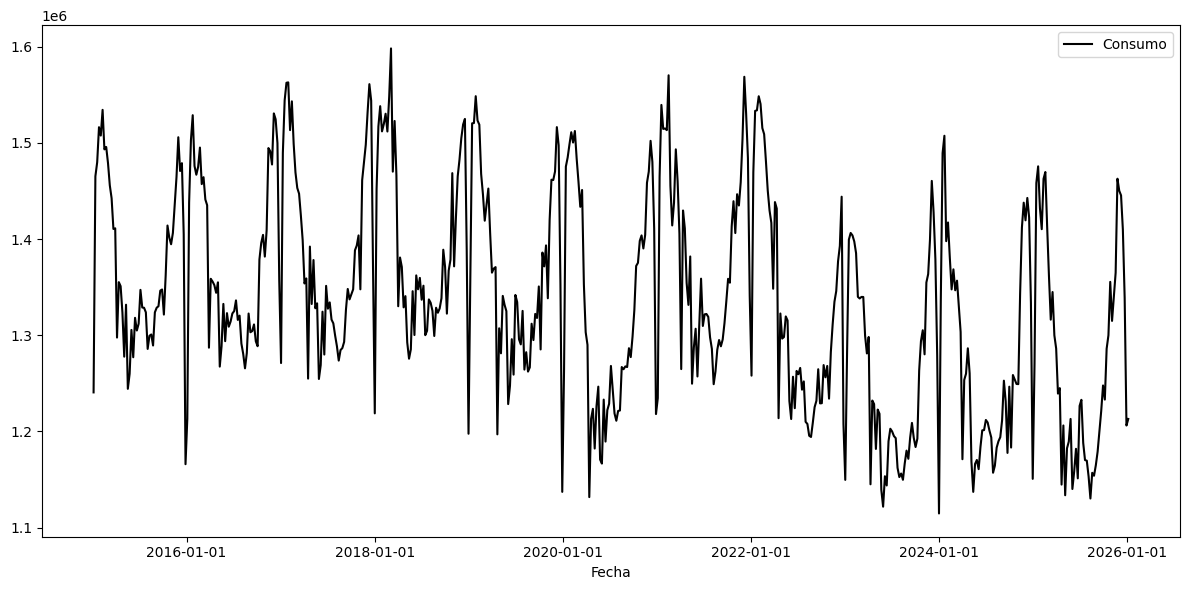

In [11]:
# # se grafican los datos de consumo de forma semanal
plt.figure(figsize=(12,6))
plt.plot(df_data_close["Start date"], df_data_close["value"], label="Consumo", color="black")
#plt.plot(df_data_close2["Date"], df_data_close2["Value"], color="blue")
plt.xlabel("Fecha")
#plt.ylabel("Consumo")
plt.legend()

# esta parte es para que las fechas en el eje x se vean mejor
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # se ajusta el espaciado de las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # se formatea la fechas
#plt.grid(True)
plt.tight_layout()# se ajusta el layout para que no se corten los elementos
plt.show()

Primeramente se separan los datos en los conjuntos train y test para validar el rendimiento del modelo final mediante datos no vistos. Se toma el 90% del total de datos como conjunto de entrenamiento y el 10% restante como conjunto de validación. Se realiza dicha división y se grafica

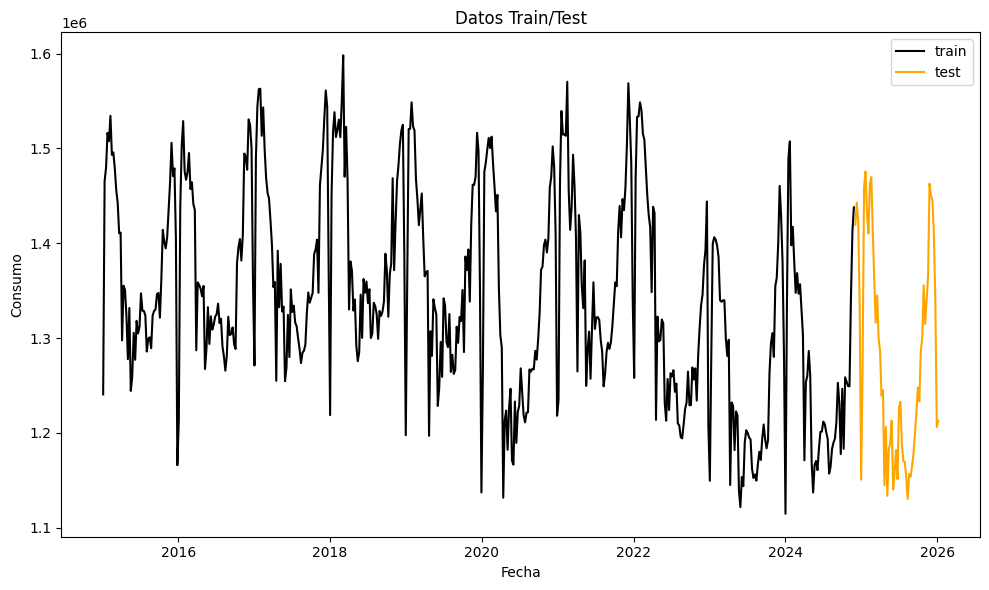

In [12]:
# se divide en train/test y se trabaja con train para fijar el modelo
train, test = train_test_split(df_data_close, test_size=0.1, shuffle=False)
train = train.sort_values(by="Start date")
test = test.sort_values(by="Start date")

# gráfica train/test
plt.figure(figsize=(10,6))
plt.plot(train["Start date"], train["value"], label="train", color="black")
plt.plot(test["Start date"], test["value"], label="test", color="orange")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
plt.legend()
plt.title("Datos Train/Test")
plt.tight_layout()
#plt.grid(True)
plt.show()

El estudio de las propiedades estadísticas se hará en el conjunto de train, se fijará un modelo y luego se generarán predicciones a partir de dicho modelo para compararlas con el conjunto de testeo

In [13]:
print(f"train len: {len(train)}")
print(f"test len: {len(test)}")

train len: 517
test len: 58


In [14]:
# calculamos la media de la serie train
train_data_mean = train["value"].mean()
train_data_mean

1344470.7318181817

## Definición manual de órdenes

Se establece un modelo preliminar siguiendo la metodología Box-Jenkins. 

A primera vista, se aprecia que la serie oscila alrededor de la media, por lo que no se requiere aplicar transformaciones estabilizadoras de varianza. Aplicamos el test de Dickey-Fuller para validar estacionariedad

In [15]:
# se valida estacionariedad de la serie
check_stationarity(train["value"])

ADF Statistic: -5.1166898303901229
p-value: 0.0000129751898812
Estacionaria


como el valor p es menor que el nivel de significancia (0.05), se tiene que raíces de la componente AR estan por fuera del circulo intario y asi se tiene que la serie es estacionaria por lo que d = 0. Ahora miramos la ACF y la PACF de train. La serie además parece presentar cierta periodicidad, por lo que se examinan las posibles frecuencias de la serie mediante el periodograma

Periodo dominante estimado: 51.70


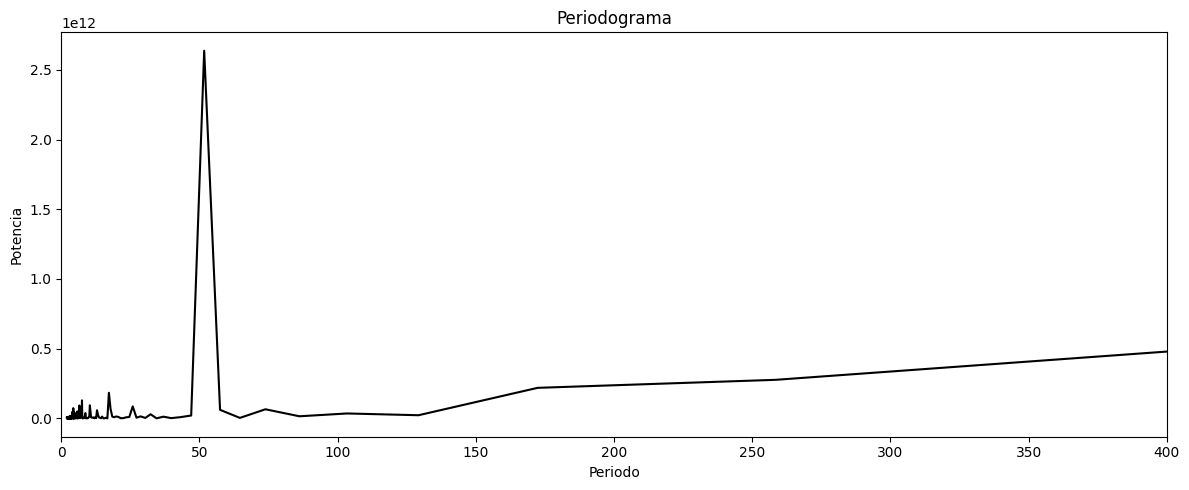

In [16]:
#periodograma
# 1. Preparación


train_copy = train.sort_values("Start date").copy()
train_copy["Start date"] = pd.to_datetime(train_copy["Start date"])
train_copy = train_copy.set_index("Start date")

# Ajustar frecuencia
train_copy = train_copy.asfreq("W-MON") # frecuencia semanal con inicio el lunes (así se agrupo)

serie = train_copy["value"].dropna().values

# 2. Periodograma clásico
fs = 1  # 1 observación por unidad temporal
frequencies, power = periodogram(serie, fs=fs)


# 3. Periodograma en términos de periodo
frequencies_nonzero = frequencies[1:]
power_nonzero = power[1:]

periods = 1 / frequencies_nonzero

# Detectar periodo dominante
idx_max = np.argmax(power_nonzero)
periodo_dominante = periods[idx_max]

print(f"Periodo dominante estimado: {periodo_dominante:.2f}")


# 4. Welch (suavizado)
frequencies_w, power_w = welch(serie, fs=1, nperseg=min(256, len(serie)))
frequencies_w_nz = frequencies_w[1:]
power_w_nz = power_w[1:]
periods_w = 1 / frequencies_w_nz


# 5. Gráficas

plt.figure(figsize=(12,5))
#plt.subplot(1,2,1)
plt.plot(periods, power_nonzero, color="black")
plt.title("Periodograma")
plt.xlabel("Periodo")
plt.ylabel("Potencia")
plt.xlim(0, min(400, periods.max()))
#plt.grid(True)

#plt.subplot(1,2,2)
#plt.plot(periods_w, power_w_nz)
#plt.title("Welch Periodogram")
##plt.xlabel("Periodo")
#plt.ylabel("Potencia")
#plt.xlim(0, min(400, periods_w.max()))
#plt.grid(True)

plt.tight_layout()
plt.show()

Se logra apreciar tanto en el periodograma clásico como en el escalado que se presenta un pico fuerte alrededor de s = 51.7 (approx 52) es esperable debido a los comportamientos cíclicos que puede tener dicho consumo. Ahora examinamos la ACF y la PACF para validar los posibles órdenes de las componentes p y q (componentes ARIMA puro) y determinar el orden de diferenciación estacionadl (D)de ser necesario

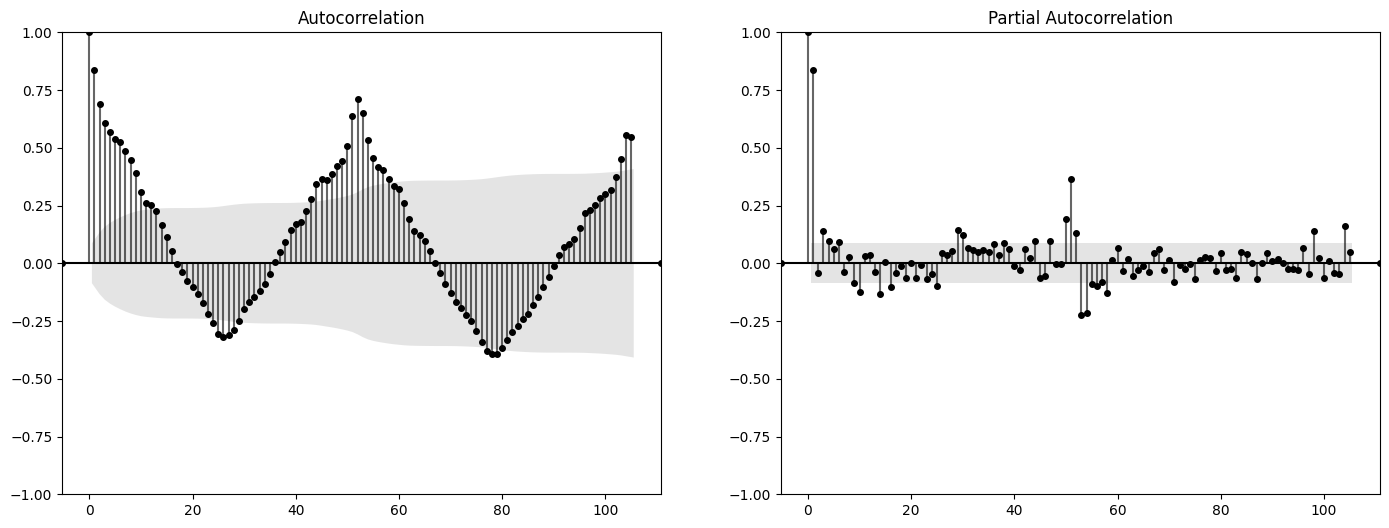

In [17]:
# e grafica ahora la acf de la train, se hace para rezagos cortos (20) 

plot_acf_pacf(train["value"], n_lags=105)


en la PACF puede verse una dependencia fuerte respecto al rezago 1, rezago despues del cual los valores decaen de forma significativa. La ACF decae de forma suave. En conjunto, parecen indicar que el proceso sigue un modelo AR(1)

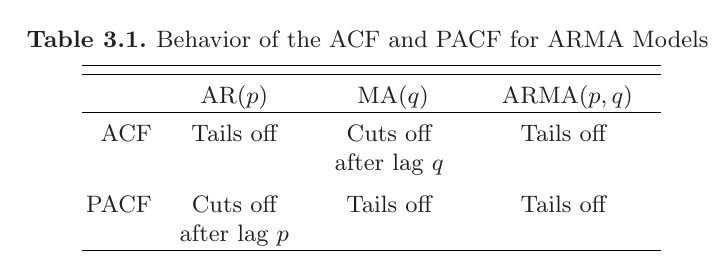

De forma preliminar, se establecen los órdenes p,d,q respectivamente como 
- p = 1
- d = 0
- q = 0


Para la parte estacional, se miran las ACF y PACF para los valores ks (s = 52), k $\geq$ 1



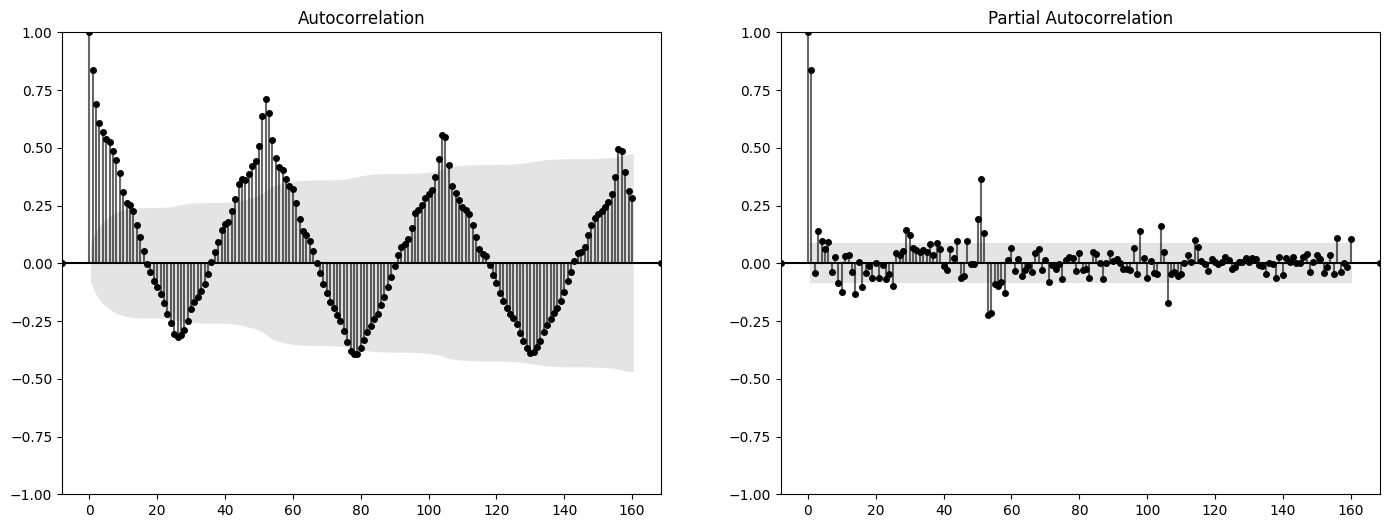

In [18]:
# e grafica ahora la acf de la train, se hace para rezagos cortos (20) 

plot_acf_pacf(train["value"], n_lags=160)

Se tiene que los valores ks decaen de forma alternada, con variaciones significativas respecto a 1. Esto podría indicar que D = 0. 

Además en la ACF se presenta un decaimiento lento para los valores ks mientras que en la PACF se muestran picos en dichos valores, sin embargo se tiene que el pico significativo respecto a la estacionalidad ocurre en 1s (rezago 52), dado que para los demás rezagos se aprecian variaciones significativas. Esto podría indicar que la componente estacional tiene orden 1

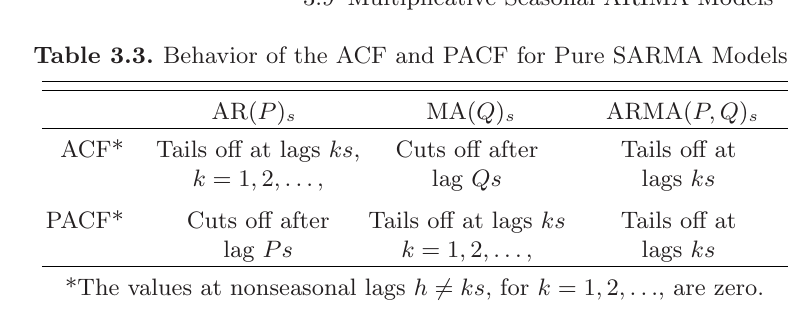

In [25]:
# serie transformada
diff_train = train_copy.diff(52).dropna()
# acf y pacf
diff_train

,value
Start date,
2016-01-04,-27346.778571
2016-01-11,-27328.607143
2016-01-18,22861.107143
2016-01-25,12482.714286
2016-02-01,-31650.785714
...,...
2024-10-28,-55807.678571
2024-11-04,-30979.392857
2024-11-11,-11783.428571


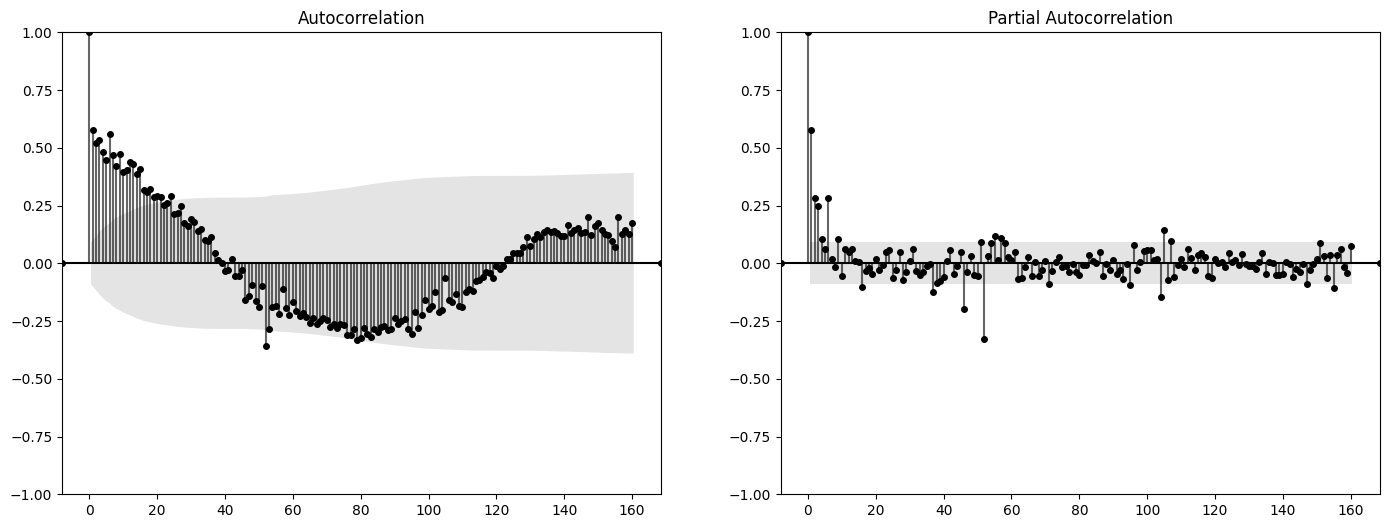

In [26]:


plot_acf_pacf(diff_train["value"], n_lags=160)

In [27]:
# se aplica dickey-fuller a train_diff
check_stationarity(diff_train["value"])

ADF Statistic: -3.1403758789349809
p-value: 0.0237059326654897
Estacionaria


Se obtiene entonces el siguiente modelo $\text{SARIMA}(1,0,0) \times (1,0,0)_{[52]}$, definido como $$(1-\phi_1B)(1-\Phi_1 B^{s})x_t = \delta+ \omega_t$$
Se determinan entonces los coeficientes de las partes estacional y no estacional y se realizan las predicciones

In [ ]:
# fijar modelo manual
p = 1 # orden AR(p) no estacional
d = 0 # diferenciación no estacional
q = 0 # orden MA(q) no estacional
P = 1 # orden AR(P) estacional
D = 1 # diferenciación estacional
Q = 0 # orden MA(Q) estacional

model = sm.tsa.statespace.SARIMAX(
    train_copy["value"], 
    order = (1,0,0), # ARIMA(p,d,q)
    seasonal_order= (1,0,0,52), # componentes estacionales
    enforce_invertibility=False,
    enforce_stationarity=False 
)

results = model.fit(method='lbfgs', maxiter=100, disp=False)

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              value   No. Observations:                  517
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 52)   Log Likelihood               -5716.360
Date:                            Wed, 11 Mar 2026   AIC                          11438.721
Time:                                    22:21:55   BIC                          11451.140
Sample:                                01-05-2015   HQIC                         11443.609
                                     - 11-25-2024                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9975      0.005    213.891      0.000       0.988       1.007
ar.S.L52       0.4803      0.031     15.741      0.000       0.420       0.540
sigma2      3.648e+09   5.33e-13   6.85e+21      0.000    3.65e+09    3.65e+09
===================================================================================
Ljung-Box (L1) (Q):                  39.75   Jarque-Bera (JB):               114.09
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.26   Skew:                             0.06
Prob(H) (two-sided):                  0.15   Kurtosis:                         5.43
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.12e+38. Standard errors may be unstable.
"""

Se obtiene entonces que los coeficientes hallados para el modelo son
$$
\phi_1 = 0.9975,
\Phi_1 = 0.4803
$$
El valor del AIC (criterio de información de Akaike) es 11438.721. Se evalua el comportamiento de los residuos (QQplot y test ljung-box para correlacion)

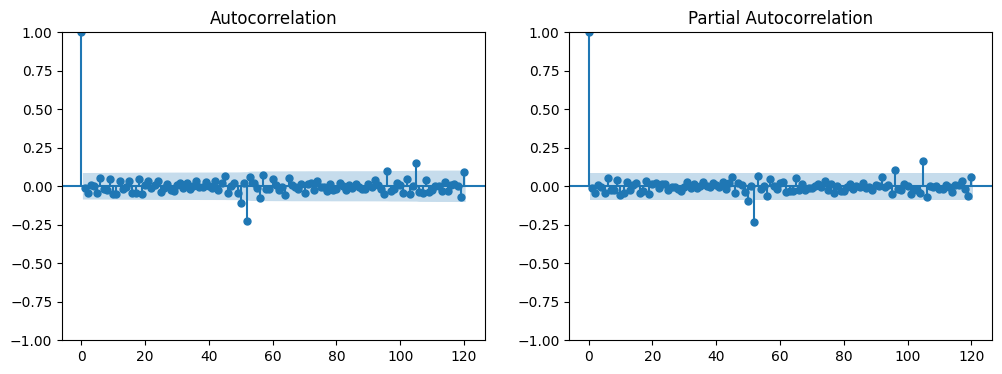

In [26]:
plot_acf_pacf(results.resid, n_lags=120) # ACF y pACF de residuops


Ljung-Box: H0: no hay autocorrelación hasta el lag h. Si el valor p es mayor al nivel de significancia (0.05), No se rechaza H0, es decir, no hay evidencia de autocorrelación residual entre los residuos

In [27]:
print(acorr_ljungbox(results.resid, lags=[10,20,40,52,60,80,104,114,124,134,144,156], return_df=True))

        lb_stat  lb_pvalue
10     6.617318   0.761011
20    14.029663   0.828989
40    19.180125   0.997819
52    62.525122   0.150555
60    73.131941   0.118822
80    81.451633   0.433791
104   97.026285   0.673025
114  117.868158   0.383088
124  129.562519   0.348170
134  134.106455   0.481163
144  136.291729   0.663891
156  159.916232   0.398373


Se logra apreciar que para los rezagos seleccionados el valor p (lb_pvalue) es mayor a 0.05 en todos los casos, por lo que se infiere que no existe correlación significativa hasta el rezago 156. Respecto a la QQ plot

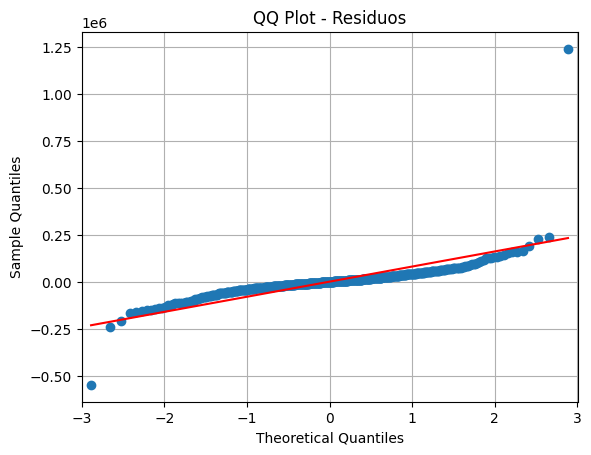

In [28]:
# gráfica QQplot
residuals = results.resid.dropna()
sm.qqplot(residuals, line="s")
plt.title("QQ Plot - Residuos")
plt.grid(True)
plt.show()

Logra apreciarse que los cuantiles muestrales logran una aproximación uniforme a los cuantiles teóricos, lo que indica que lo reiduos siguen aproximandamente una distribución normal: Hay valores atípicos, lo que puede deberse a valores extremos en la serie. Se concluye, siguiendo la metodología Box-Jenkins, que el modelo es aceptable y se pasa a la parte de validación. El modelo genera predicciones y luego se calculan las métricas de error

In [29]:
# predicciones
forecast_index = test.index
# Número de pasos a predecir
n_forecast = len(test)

forecast = results.get_forecast(steps=n_forecast)

# Media predicha
forecast_mean = forecast.predicted_mean

# Intervalos de confianza
forecast_ci = forecast.conf_int()

forecast_df = pd.DataFrame({
    "forecast": forecast_mean.values,
    "lower_ci": forecast_ci.iloc[:, 0].values,
    "upper_ci": forecast_ci.iloc[:, 1].values
}, index=forecast_index) 

forecast_df.head()

,forecast,lower_ci,upper_ci
517,1.465209e+06,1.346833e+06,1.583586e+06
518,1.447674e+06,1.280474e+06,1.614874e+06
519,1.422235e+06,1.217714e+06,1.626756e+06
520,1.372369e+06,1.136504e+06,1.608235e+06
521,1.291538e+06,1.028161e+06,1.554914e+06


In [30]:
# cálculo de errores
y_true = test["value"]
y_pred = forecast_df["forecast"]


smape_fn = MeanAbsolutePercentageError(symmetric=True)
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true))
smape = smape_fn(y_true, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape*100:.4f}%")
print(f"sMAPE: {smape*100:.4f}%")


MAE: 70529.22099371835
RMSE: 84545.30481170242
MAPE: 5.7647%
sMAPE: 5.5647%


Aunque el MAPE y el sMAPE presentan valores relativamente pequeños, se presentan diferencias significativas respecto a las distancias entre los valores reales y predichos, reflejados por el MAE y el RMSE. Puede deberse a que algunas variaciones no fueron captadas adecuadamente por las componentes, lo que sugiere que el modelo puede mejorarse para determinar mejores órdenes para las componentes no relacionadas con la diferenciacíon y la diferenciación estacional.

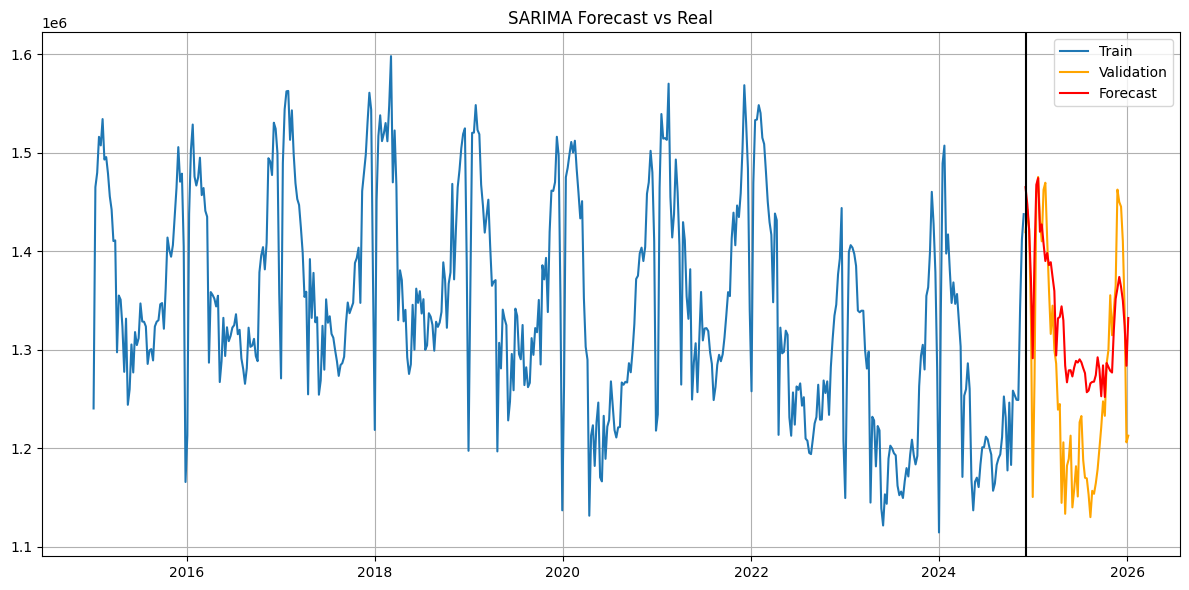

In [31]:
# Ajuste visual
plt.figure(figsize=(12,6))

# Datos reales
plt.plot(train["Start date"], train["value"], label="Train")
plt.plot(test["Start date"], test["value"], label="Validation", color="orange")

# Predicción
plt.plot(test["Start date"], forecast_df["forecast"], 
         label="Forecast", color="red")


#linea

plt.axvline(test["Start date"].values[0], color="black")
""" # Intervalos
plt.fill_between(
    test["Start date"],
    forecast_df["lower_ci"],
    forecast_df["upper_ci"],
    color="red",
    alpha=0.2
) """

plt.legend()
plt.title("SARIMA Forecast vs Real")
plt.grid(True)
plt.tight_layout()
plt.show()

se exportan los datos para validar las predicciones conjuntas

In [32]:
y_pred

517    1.465209e+06
518    1.447674e+06
519    1.422235e+06
520    1.372369e+06
521    1.291538e+06
522    1.395918e+06
523    1.467666e+06
524    1.474447e+06
525    1.419939e+06
526    1.427397e+06
527    1.408002e+06
528    1.390246e+06
529    1.398392e+06
530    1.386085e+06
531    1.389018e+06
532    1.374108e+06
533    1.359741e+06
534    1.294345e+06
535    1.332100e+06
536    1.333407e+06
537    1.344226e+06
538    1.329950e+06
539    1.283992e+06
540    1.267102e+06
541    1.279238e+06
542    1.279428e+06
543    1.273041e+06
544    1.282282e+06
545    1.288840e+06
546    1.287170e+06
547    1.290442e+06
548    1.287405e+06
549    1.281556e+06
550    1.276391e+06
551    1.257031e+06
552    1.258792e+06
553    1.266094e+06
554    1.267507e+06
555    1.267767e+06
556    1.274432e+06
557    1.292498e+06
558    1.280513e+06
559    1.252971e+06
560    1.284315e+06
561    1.252209e+06
562    1.286708e+06
563    1.282711e+06
564    1.278834e+06
565    1.277035e+06
566    1.320434e+06


In [33]:
arr_preds = []
for index, value in enumerate(test["Start date"].values):
    dict_pred = {
        "Date":  np.datetime_as_string(value, unit="D"), # convierte a la fecha a string para poder exportar a json
        "pred" : float(y_pred.values[index])
    }
    arr_preds.append(dict_pred)
arr_preds

[{'Date': '2024-12-02', 'pred': 1465209.2791851468},
 {'Date': '2024-12-09', 'pred': 1447673.8932404313},
 {'Date': '2024-12-16', 'pred': 1422234.9949237849},
 {'Date': '2024-12-23', 'pred': 1372369.223215145},
 {'Date': '2024-12-30', 'pred': 1291537.5453525693},
 {'Date': '2025-01-06', 'pred': 1395918.1991828522},
 {'Date': '2025-01-13', 'pred': 1467666.289621186},
 {'Date': '2025-01-20', 'pred': 1474446.6999478573},
 {'Date': '2025-01-27', 'pred': 1419939.1161592724},
 {'Date': '2025-02-03', 'pred': 1427396.9304219098},
 {'Date': '2025-02-10', 'pred': 1408002.408870825},
 {'Date': '2025-02-17', 'pred': 1390245.5097068325},
 {'Date': '2025-02-24', 'pred': 1398391.5720215905},
 {'Date': '2025-03-03', 'pred': 1386085.2963757205},
 {'Date': '2025-03-10', 'pred': 1389018.1470545074},
 {'Date': '2025-03-17', 'pred': 1374108.0114262695},
 {'Date': '2025-03-24', 'pred': 1359740.8115485115},
 {'Date': '2025-03-31', 'pred': 1294344.5048674284},
 {'Date': '2025-04-07', 'pred': 1332100.096929374

In [ ]:
# Cálculo de métricas agregadas
dict_to_export = {
    "mape_val": float(mape),
    "mae_val": float(mae),
    "smape_val": float(smape),
    "rmse_val": float(rmse),
    #"predictions": forecast_df["forecast"].values.ravel().tolist()
    "predictions": arr_preds
}
""" with open ("../../../data/preds_energy_models/SARIMA_manual_preds.json", "w") as json_file:
    json.dump(dict_to_export, json_file, indent=4) """

## Grid search

Para optimizar el rendimiento del modelo se realiza una búsqueda de hiperparametros para los ordenes p, P, q, Q. Lo órdenes d, D se mantienen en su elección original dado que dependen explicitamente de la estacionariedad de la serie. Para ello se define una serie de posibles valores y se selecciona el modelo que minimiza el valor arrojado por el AIC

In [ ]:
""" 
# espacio reducido
p = q = range(0,2)
P = Q = range(0,2)

pdq = list(itertools.product(p, [0], q))
seasonal_pdq = list(itertools.product(P, [0], Q, [52]))

best_aic = float("inf")
best_model = None

for param in pdq:
    for param_seasonal in seasonal_pdq:
        print(f"Probando SARIMA{param}x{param_seasonal}")
        start = time.time()
        try:
            model = sm.tsa.statespace.SARIMAX(
                train["value"],
                order=param,
                seasonal_order=param_seasonal,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            results = model.fit(
                method='lbfgs',
                maxiter=50,
                disp=False
            )

            elapsed = time.time() - start
            print(f"AIC: {results.aic:.2f} | tiempo: {elapsed:.1f}s")

            if results.aic < best_aic:
                best_aic = results.aic
                best_model = results

        except Exception as e:
            print("Error:", e)
            continue

print("Mejor AIC:", best_aic)

if best_model is not None:
    print(best_model.summary())
 """

Probando SARIMA(0, 0, 0)x(0, 0, 0, 52)
AIC: 16032.81 | tiempo: 0.0s
Probando SARIMA(0, 0, 0)x(0, 0, 1, 52)
AIC: 14096.71 | tiempo: 1.8s
Probando SARIMA(0, 0, 0)x(1, 0, 0, 52)
AIC: 11660.35 | tiempo: 0.7s
Probando SARIMA(0, 0, 0)x(1, 0, 1, 52)
AIC: 11637.89 | tiempo: 2.8s
Probando SARIMA(0, 0, 1)x(0, 0, 0, 52)
AIC: 15627.80 | tiempo: 0.1s
Probando SARIMA(0, 0, 1)x(0, 0, 1, 52)
AIC: 13969.68 | tiempo: 2.6s
Probando SARIMA(0, 0, 1)x(1, 0, 0, 52)
AIC: 13986.97 | tiempo: 1.2s
Probando SARIMA(0, 0, 1)x(1, 0, 1, 52)
AIC: 13928.78 | tiempo: 2.4s
Probando SARIMA(1, 0, 0)x(0, 0, 0, 52)
AIC: 12829.32 | tiempo: 0.1s
Probando SARIMA(1, 0, 0)x(0, 0, 1, 52)
AIC: 11465.39 | tiempo: 7.1s
Probando SARIMA(1, 0, 0)x(1, 0, 0, 52)
AIC: 11438.72 | tiempo: 2.9s
Probando SARIMA(1, 0, 0)x(1, 0, 1, 52)
AIC: 11438.53 | tiempo: 7.4s
Probando SARIMA(1, 0, 1)x(0, 0, 0, 52)
AIC: 12792.60 | tiempo: 0.1s
Probando SARIMA(1, 0, 1)x(0, 0, 1, 52)
AIC: 11408.84 | tiempo: 3.0s
Probando SARIMA(1, 0, 1)x(1, 0, 0, 52)
AIC: 1138

In [ ]:
""" best_model.summary() """

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              value   No. Observations:                  517
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 52)   Log Likelihood               -5667.186
Date:                            Wed, 11 Mar 2026   AIC                          11344.372
Time:                                    22:22:41   BIC                          11365.061
Sample:                                         0   HQIC                         11352.516
                                            - 517                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9975      0.004    265.505      0.000       0.990       1.005
ma.L1         -0.4795      0.033    -14.618      0.000      -0.544      -0.415
ar.S.L52       0.6608      0.036     18.256      0.000       0.590       0.732
ma.S.L52      -0.0776      0.023     -3.343      0.001      -0.123      -0.032
sigma2      3.562e+09   1.67e-12   2.14e+21      0.000    3.56e+09    3.56e+09
===================================================================================
Ljung-Box (L1) (Q):                   0.36   Jarque-Bera (JB):               177.27
Prob(Q):                              0.55   Prob(JB):                         0.00
Heteroskedasticity (H):               1.26   Skew:                            -0.65
Prob(H) (two-sided):                  0.15   Kurtosis:                         5.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.86e+37. Standard errors may be unstable.
"""

Respecto al AIC logra apreciarse una mejora respecto al valor del modelo inicial. Se nota además que a diferencia del modelo inicial, el mejor modelo encontrado por la busqueda de hiperparametros definio ordenes para las componentes ma(q) pura y ma(Q) estacional, obteniendo que el modelo es de la forma $\text{SARIMA}(1,0,1) \times (1,0,1)_{[52]}$, definido como $$(1-\phi_1B)(1-\Phi_1 B^{s})x_t = \delta+ (1+\theta_1 B)(1 + \Theta_1 B^s)\omega_t$$

con $ \phi_1 = 0.9299, \Phi_1 = -0.2662, \theta_1 = -0.5831, \Theta_1 = -0.1305 $.

Se valida el comportamiento de los residuos de forma análoga al modelo anterior

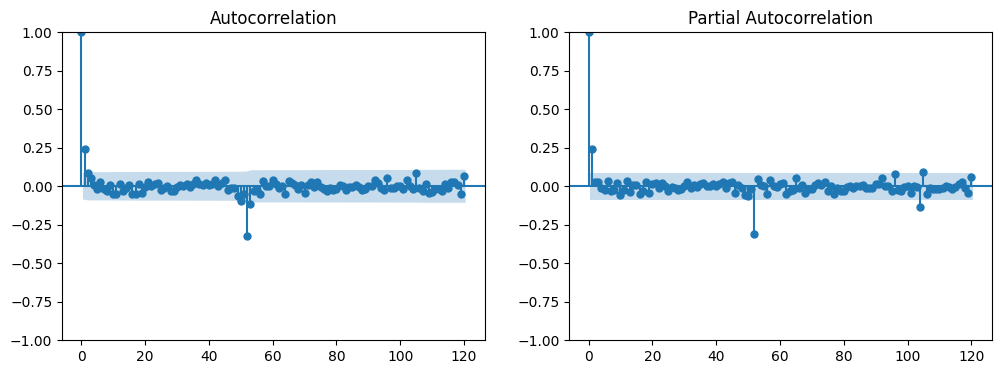

In [37]:
plot_acf_pacf(best_model.resid, n_lags=120) # ACF y pACF de residuops

In [ ]:
""" print(acorr_ljungbox(best_model.resid, lags=[10,20,40,52,60,80,104,114,124,134,144,156], return_df=True)) """

        lb_stat     lb_pvalue
10    38.799734  2.752233e-05
20    44.576681  1.258959e-03
40    48.666176  1.635430e-01
52   120.465097  2.351846e-07
60   132.366167  2.260950e-07
80   138.729976  5.163070e-05
104  145.159254  4.788341e-03
114  153.704969  7.816463e-03
124  160.188412  1.587485e-02
134  163.044912  4.454953e-02
144  163.966614  1.220010e-01
156  170.960915  1.952253e-01


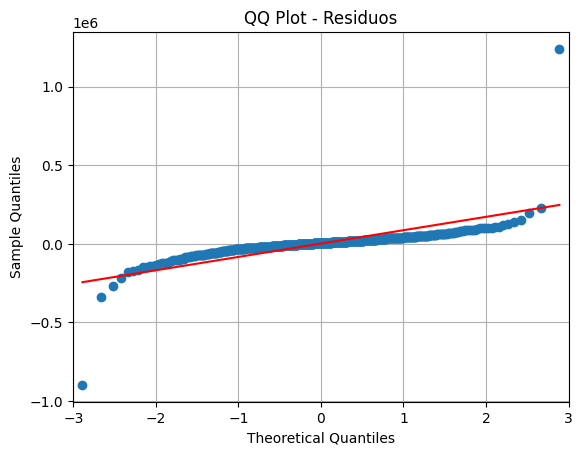

In [ ]:
""" # gráfica QQplot
residuals = best_model.resid.dropna()
sm.qqplot(residuals, line="s")
plt.title("QQ Plot - Residuos")
plt.grid(True)
plt.show() """

In [ ]:
""" # predicciones
forecast_index = test.index
# Número de pasos a predecir
n_forecast = len(test)

forecast = results.get_forecast(steps=n_forecast)

# Media predicha
forecast_mean = forecast.predicted_mean

# Intervalos de confianza
forecast_ci = forecast.conf_int()

forecast_df = pd.DataFrame({
    "forecast": forecast_mean.values,
    "lower_ci": forecast_ci.iloc[:, 0].values,
    "upper_ci": forecast_ci.iloc[:, 1].values
}, index=forecast_index) 

forecast_df.head() """

,forecast,lower_ci,upper_ci
517,1.450441e+06,1.333473e+06,1.567409e+06
518,1.430747e+06,1.299017e+06,1.562478e+06
519,1.403002e+06,1.258066e+06,1.547937e+06
520,1.332208e+06,1.175232e+06,1.489184e+06
521,1.232154e+06,1.064051e+06,1.400258e+06


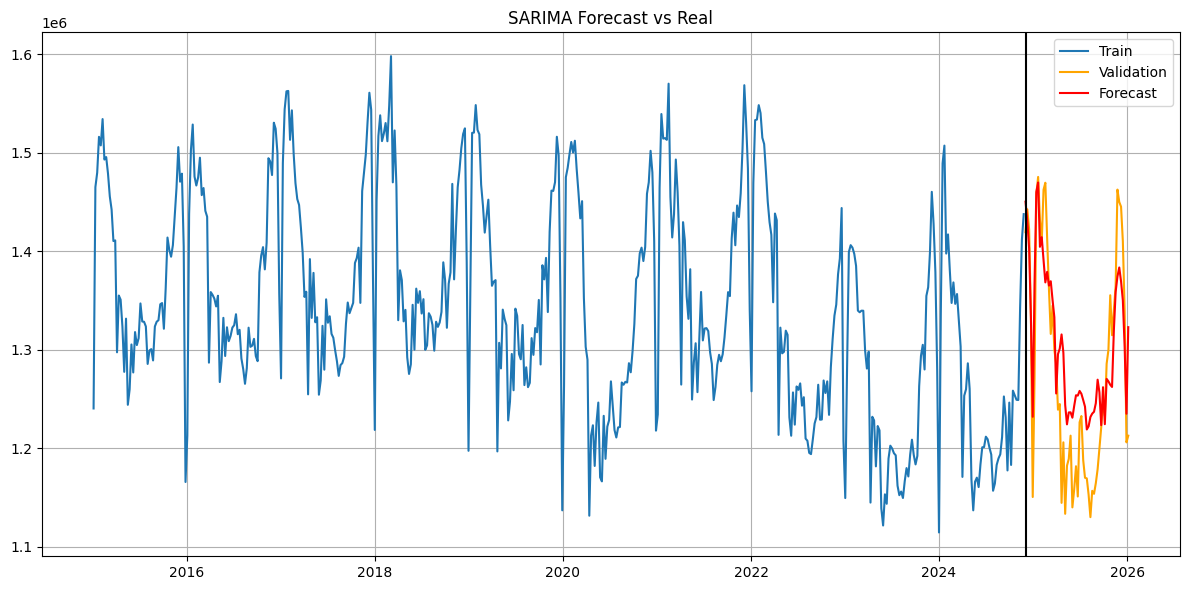

In [ ]:
""" # Ajuste visual
plt.figure(figsize=(12,6))

# Datos reales
plt.plot(train["Start date"], train["value"], label="Train")
plt.plot(test["Start date"], test["value"], label="Validation", color="orange")

# Predicción
plt.plot(test["Start date"], forecast_df["forecast"], 
         label="Forecast", color="red")


#linea

plt.axvline(test["Start date"].values[0], color="black")
""" # Intervalos
plt.fill_between(
    test["Start date"],
    forecast_df["lower_ci"],
    forecast_df["upper_ci"],
    color="red",
    alpha=0.2
) """

plt.legend()
plt.title("SARIMA Forecast vs Real")
plt.grid(True)
plt.tight_layout()
plt.show() """